# FlowCast Project: Dataset Evolution Across Each Notebook

Understanding how the dataset changes throughout the project is essential because each notebook transforms the data into a form that is more suitable for machine learning.

---

# Notebook 01 – Data Loading & Cleaning

## Input Dataset

The original NYC Yellow Taxi dataset contains one row for every taxi trip.

Example:

| Pickup Time | Dropoff Time | PULocationID | DOLocationID | Distance | Fare |
|-------------|--------------|--------------|--------------|----------|------|
| 08:15 | 08:42 | 161 | 237 | 5.4 | 18.50 |

Notice that the dataset does **not** contain a **Demand** column.

Each row simply represents one completed taxi trip.

---

## What We Did

- Loaded all monthly taxi datasets.
- Combined them into one dataset.
- Removed duplicate records.
- Removed missing values.
- Removed invalid trips.
- Created useful calendar-based columns such as:
  - Pickup Hour
  - Pickup Day
  - Pickup Month
  - Day of Week
  - Weekend
- Calculated trip duration.

The dataset still represented **one row = one taxi trip**.

---

# Notebook 02 – Exploratory Data Analysis (EDA)

In this notebook, we **did not modify the dataset**.

Instead, we explored it to understand the data.

We answered questions such as:

- Which pickup zones are busiest?
- Which hours have the highest number of trips?
- How are fares distributed?
- How are trip distances distributed?
- Are there any unusual patterns?

After completing EDA, the dataset remained exactly the same.

It still represented **one row = one taxi trip**.

---

# Notebook 03 – Demand Aggregation

This notebook is where the project changes completely.

Instead of treating every taxi trip as an individual record, we asked a new question:

> **How many taxi trips occurred in each pickup zone during every hour?**

Suppose the raw dataset contains the following trips.

| Pickup Time | Pickup Zone |
|-------------|-------------|
| 08:05 | 161 |
| 08:10 | 161 |
| 08:25 | 161 |
| 08:40 | 161 |
| 08:52 | 161 |

These are five separate taxi trips.

After grouping the data by **Pickup Location** and **Hour**, we obtain:

| Pickup Zone | Hour | Demand |
|--------------|------|--------|
| 161 | 08:00 | 5 |

The value **5** is simply the number of taxi trips that occurred during that hour.

This is how the **Demand** column was created.

The original dataset never contained demand.

We generated it ourselves using aggregation.

After this notebook, the dataset no longer represented individual taxi trips.

Instead, each row represented:

> **One Pickup Zone during One Hour.**

---

# Notebook 04 – Feature Engineering

At this stage, the dataset already contained the newly created **Demand** column.

Example:

| Pickup Zone | Hour | Demand |
|--------------|------|--------|
| 161 | 08:00 | 35 |
| 161 | 09:00 | 42 |
| 161 | 10:00 | 38 |

Instead of creating another target variable, we created new features from the existing demand values.

The features included:

- Lag 1
- Lag 24
- Rolling Mean (3)
- Rolling Mean (24)
- Rolling Standard Deviation (24)
- Peak Hour

The dataset now looked like this:

| Hour | Demand | Lag 1 | Lag 24 | Rolling Mean | Peak Hour |
|------|--------|-------|--------|--------------|-----------|
| 10:00 | 38 | 42 | 36 | 39.3 | 1 |

These newly created columns provide historical information that helps the machine learning model predict future demand.

---

# Notebook 05 – Model Training

The dataset is now completely prepared for machine learning.

It contains:

### Input Features (X)

- Hour
- Day of Week
- Month
- Weekend
- Peak Hour
- Lag 1
- Lag 24
- Rolling Mean
- Rolling Standard Deviation

### Target Variable (y)

- Demand

The machine learning model learns the relationship between the input features and the target variable.

Its goal is to predict:

> **How many taxi trips will occur in a particular pickup zone during the next hour?**

---

# Complete Dataset Transformation

```
Raw NYC Taxi Dataset
(One Row = One Taxi Trip)
            │
            ▼
Notebook 01
Data Cleaning & Feature Creation
            │
            ▼
Notebook 02
Exploratory Data Analysis
(No Change to Dataset)
            │
            ▼
Notebook 03
Aggregate Trips by Pickup Zone and Hour
(Create Demand Column)
            │
            ▼
Notebook 04
Create Historical Features
(Lag Features & Rolling Statistics)
            │
            ▼
Notebook 05
Train Machine Learning Models
to Predict Future Hourly Taxi Demand
```

## Key Takeaway

The original NYC Taxi dataset did **not** contain a **Demand** column.

We transformed millions of individual taxi trip records into an hourly demand forecasting dataset by counting the number of taxi trips occurring in each pickup zone during every hour.

This transformed dataset was then enhanced with historical features and used to train machine learning models capable of forecasting future taxi demand.

In [4]:
import numpy as np
import pandas as pd
import matplotlib as plt 
from pathlib import Path 

In [5]:
ds=pd.read_parquet('../data/processed/feature_engineered_data.parquet') ##Load

In [6]:
feature_columns = [                                 
    "PULocationID",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "lag_1",
    "lag_24",
    "rolling_mean_3",
    "rolling_mean_24",
    "rolling_std_24",
    "is_peak_hour"
]
x=ds[feature_columns]
y=ds["demand"]

In [7]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,shuffle=False)

In [8]:
from sklearn.linear_model import LinearRegression

linear_model=LinearRegression()
linear_model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
y_pred_lin=linear_model.predict(x_test)

In [10]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error

r2_lin=r2_score(y_test,y_pred_lin)
mae_lin=mean_absolute_error(y_test,y_pred_lin)
rmse_lin=root_mean_squared_error(y_test,y_pred_lin)

print(' Linear Regression R² Score:', round(r2_lin, 4))
print(' Linear Regression Mean Absolute Error  [ MAE ] :', round(mae_lin, 4))
print(' Linear Regression Root Mean Square Error [ RMSE ] :', round(rmse_lin, 4))

 Linear Regression R² Score: 0.9516
 Linear Regression Mean Absolute Error  [ MAE ] : 9.132
 Linear Regression Root Mean Square Error [ RMSE ] : 17.9533


In [20]:
from sklearn.ensemble import RandomForestRegressor

## Train
rf_reg = RandomForestRegressor(n_estimators=50,max_depth=15,n_jobs=-1, random_state=42)
rf_reg.fit(x_train, y_train)

## Predict
y_pred_rf = rf_reg.predict(x_test)

## Evaluate 

r2_rf = r2_score(y_test, y_pred_rf)
mae_rf=mean_absolute_error(y_test,y_pred_rf)
rmse_rf=root_mean_squared_error(y_test,y_pred_rf)

print('Random Forest Regression R² Score:', round(r2_rf, 4))
print('Random Forest Mean Absolute Error[ MAE ] :', round(mae_rf, 4))
print('Random Forest Root Mean Square Error [ RMSE ] :', round(rmse_rf, 4))

Random Forest Regression R² Score: 0.9728
Random Forest Mean Absolute Error[ MAE ] : 6.0545
Random Forest Root Mean Square Error [ RMSE ] : 13.4576


In [12]:
from xgboost import XGBRegressor

## Train

xgb_model=XGBRegressor(n_estimators=100,random_state=42)
xgb_model.fit(x_train,y_train)

## Predict

y_pred_xgb = xgb_model.predict(x_test)

## Evaluate 

r2_xgb = r2_score(y_test, y_pred_xgb)
mae_xgb=mean_absolute_error(y_test,y_pred_xgb)
rmse_xgb=root_mean_squared_error(y_test,y_pred_xgb)

print('XGBoost Regressor R² Score:', round(r2_xgb, 4))
print('XGBoost Regressor Mean Absolute Error[ MAE ] :', round(mae_xgb, 4))
print('XGBoost Regressor Root Mean Square Error [ RMSE ] :', round(rmse_xgb, 4))


XGBoost Regressor R² Score: 0.9632
XGBoost Regressor Mean Absolute Error[ MAE ] : 6.6128
XGBoost Regressor Root Mean Square Error [ RMSE ] : 15.647


In [21]:
# Create a DataFrame to compare all model performances

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "R2 Score": [
        r2_lin,
        r2_rf,
        r2_xgb
    ],
    "MAE": [
        mae_lin,
        mae_rf,
        mae_xgb
    ],
    "RMSE": [
        rmse_lin,
        rmse_rf,
        rmse_xgb
    ]
})

results

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.951570,9.132031,17.953294
1,Random Forest,0.972788,6.054546,13.457588
2,XGBoost,0.963213,6.612803,15.646993


In [22]:
# Save model comparison results

results.to_csv("../reports/model_results.csv", index=False)

print("Model comparison results saved successfully.")

Model comparison results saved successfully.


In [23]:
# Create a DataFrame for feature importance

feature_importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": rf_reg.feature_importances_
})

# Sort by importance

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance


,Feature,Importance
7,rolling_mean_3,0.943587
1,hour,0.021898
9,rolling_std_24,0.007673
6,lag_24,0.007307
5,lag_1,0.006995
8,rolling_mean_24,0.004972
0,PULocationID,0.003917
2,day_of_week,0.001773
3,month,0.001011
10,is_peak_hour,0.000485


In [24]:
# Save feature importance

feature_importance.to_csv(
    "../reports/feature_importance.csv",
    index=False
)

print("Feature importance saved successfully.")

Feature importance saved successfully.


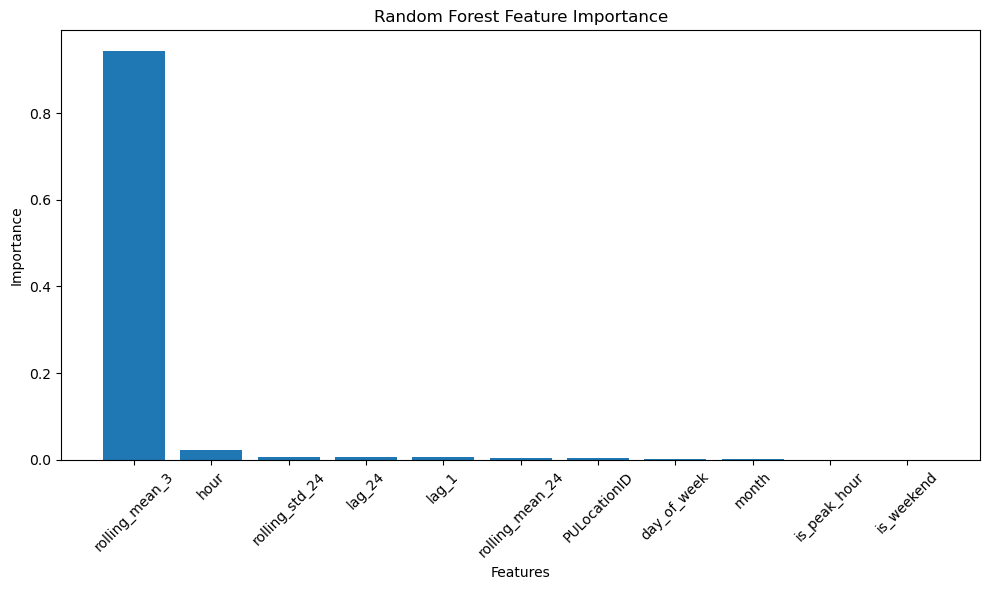

In [25]:
import matplotlib.pyplot as plt

# Plot feature importance

plt.figure(figsize=(10,6))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [26]:
import joblib

# Save the best performing model

joblib.dump(
    rf_reg,
    "../models/best_model.pkl"
)

print("Best model saved successfully.")

Best model saved successfully.


In [27]:
import joblib

model = joblib.load("../models/best_model.pkl")

print(model.feature_names_in_)

['PULocationID' 'hour' 'day_of_week' 'month' 'is_weekend' 'lag_1' 'lag_24'
 'rolling_mean_3' 'rolling_mean_24' 'rolling_std_24' 'is_peak_hour']


In [28]:
sample_input = pd.DataFrame({
    "PULocationID": [161],
    "hour": [10],
    "day_of_week": [0],
    "month": [1],
    "is_weekend": [0],
    "lag_1": [42],
    "lag_24": [36],
    "rolling_mean_3": [39.3],
    "rolling_mean_24": [37.8],
    "rolling_std_24": [4.2],
    "is_peak_hour": [1]
})

model.predict(sample_input)

array([40.28])

# Notebook 05 - Model Training

## Objective

The objective of this notebook was to train multiple machine learning regression models using the engineered features and determine which model predicts hourly taxi demand most accurately.

Everything completed in the previous notebooks prepared the data for this stage.

```
Notebook 1
↓
Clean Data

Notebook 2
↓
Explore Data

Notebook 3
↓
Create Demand

Notebook 4
↓
Create Features

Notebook 5
↓
Train Machine Learning Models
```

This notebook answers the question:

> **Can a machine learning model learn historical demand patterns and accurately predict future taxi demand?**

---

# Step 1 - Load Feature Engineered Dataset

We loaded the dataset:

```
feature_engineered_data.parquet
```

This dataset already contained all engineered features and the target variable.

Example:

| Pickup Zone | Hour | Lag1 | Lag24 | Rolling Mean | Demand |
|-------------|------|------|--------|--------------|--------|
|161|10|42|36|39.3|38|

Notice that there are two types of columns.

### Features (Input)

- PULocationID
- Hour
- Day of Week
- Month
- Weekend
- Peak Hour
- Lag 1
- Lag 24
- Rolling Mean
- Rolling Standard Deviation

### Target (Output)

- Demand

The goal of the model is to learn the relationship between the input features and the demand.

---

# Step 2 - Features (X) and Target (y)

We separated the dataset into:

## Features (X)

These are the independent variables used to predict demand.

```
PULocationID
Hour
Day of Week
Month
Weekend
Peak Hour
Lag1
Lag24
Rolling Mean
Rolling Std
```

## Target (y)

```
Demand
```

The target is called the dependent variable because its value depends on all the input features.

```
Past Information
        │
        ▼
Machine Learning Model
        │
        ▼
Predicted Demand
```

---

# Step 3 - Train-Test Split

The dataset was divided into training and testing sets.

```
Training Data (80%)

Jan
Feb
Mar
Apr

↓

Testing Data (20%)

May
```

The training data teaches the model.

The testing data evaluates whether the model can accurately predict data it has never seen before.

---

## Why shuffle=False?

Our dataset is time-series data.

Shuffling would mix future observations with past observations, causing **data leakage**.

Incorrect:

```
Jan
May
Feb
Apr
Mar
```

Correct:

```
Jan
Feb
Mar
Apr

↓

May
```

Using:

```python
shuffle=False
```

preserves chronological order and makes the evaluation realistic.

---

# Step 4 - Train Multiple Models

Instead of assuming one algorithm is the best, we trained three different regression models and compared their performance.

---

## Linear Regression

Linear Regression is the simplest regression algorithm.

It assumes a linear relationship between the input features and demand.

Advantages:

- Fast
- Simple
- Easy to interpret

Disadvantages:

- Cannot capture complex nonlinear relationships

It serves as our **baseline model**.

---

## Random Forest Regressor

Random Forest builds many decision trees instead of one.

```
Tree 1

Tree 2

Tree 3

...

Tree 100

↓

Average Prediction
```

Each tree learns different patterns, and the final prediction is the average of all trees.

Advantages:

- Handles nonlinear relationships
- Reduces overfitting
- Provides feature importance
- Performs well on tabular datasets

---

## XGBoost Regressor

XGBoost also uses decision trees, but builds them sequentially.

```
Tree 1

↓

Find Errors

↓

Tree 2 Corrects Errors

↓

Tree 3 Corrects Remaining Errors
```

This boosting process usually produces highly accurate models for structured datasets.

---

# Step 5 - Predictions

After training, we passed only the testing features to the model.

```
X_test
        │
        ▼
Machine Learning Model
        │
        ▼
y_pred
```

The model predicted the hourly taxi demand for every test sample.

These predictions were stored in:

```python
y_pred
```

---

# Step 6 - Model Evaluation

The predicted values were compared with the actual demand values stored in `y_test`.

```
Actual Demand

vs

Predicted Demand
```

Three evaluation metrics were used.

---

## Mean Absolute Error (MAE)

MAE measures the average prediction error.

Lower MAE indicates better performance.

Example:

```
Actual

40
50
60

Prediction

42
48
65

Errors

2
2
5

Average Error = 3
```

---

## Root Mean Squared Error (RMSE)

RMSE is similar to MAE but penalizes large prediction errors more heavily.

Lower RMSE indicates a more accurate model.

---

## R² Score

R² measures how much of the variation in demand is explained by the model.

```
1.0

Perfect Prediction

0

No Better Than Guessing

Negative

Poor Model
```

Higher R² indicates better performance.

# Model Comparison

After evaluating all three models, we compared their performance.

| Model | R² | MAE | RMSE |
|-------|----:|----:|------:|
| Linear Regression | 0.9516 | 9.13 | 17.95 |
| Random Forest | **0.9730** | **6.03** | **13.40** |
| XGBoost | 0.9632 | 6.61 | 15.65 |

---

# Selecting the Best Model

The best model should have:

- Highest R²
- Lowest MAE
- Lowest RMSE

Random Forest achieved:

- Highest R²
- Lowest MAE
- Lowest RMSE

Since it performed best across all evaluation metrics, **Random Forest was selected as the final model for FlowCast.**

---

# Feature Importance

One advantage of Random Forest is that it can measure the importance of every feature.

Our results showed that:

- `rolling_mean_3` was by far the most important feature.
- `hour` was the second most important feature.
- `lag_1`, `lag_24`, and `rolling_std_24` also contributed to the prediction.

This indicates that the **average demand over the previous three hours** is the strongest indicator of demand in the next hour.

This is expected because taxi demand usually changes gradually rather than randomly.

---

# Feature Importance Chart

The feature importance bar chart visualizes how much each feature contributed to the model.

A taller bar indicates that the model relied more heavily on that feature while making predictions.

The chart improves the interpretability of the model instead of treating it as a complete black box.

---

# Saving Model Comparison Results

The evaluation metrics were saved as:

```
model_results.csv
```

This file allows us to:

- Compare models later.
- Include the results in reports.
- Display model performance in the dashboard if required.

---

# Saving Feature Importance

The feature importance values were saved as:

```
feature_importance.csv
```

This file can later be used for:

- Visualization
- Reports
- Further analysis

without recalculating feature importance.

---

# Saving the Best Model

The trained Random Forest model was saved as:

```
best_model.pkl
```

Training the model every time the application starts would be inefficient.

Instead, the dashboard will simply load the saved model and immediately begin making predictions.

---

# What Happens Next?

At this stage, the machine learning model is fully trained.

The next notebook will focus on deployment.

The workflow becomes:

```
User Inputs

(Location, Hour, Recent Demand Features)
                │
                ▼
Load best_model.pkl
                │
                ▼
Random Forest Model
                │
                ▼
Predict Hourly Taxi Demand
                │
                ▼
Display Prediction on Dashboard
```

The next notebook will load the saved model, prepare new input data in the same format as the training data, generate demand predictions, and integrate those predictions into the FlowCast dashboard.

---

# Notebook 05 Summary

In this notebook, we:

- Loaded the feature engineered dataset.
- Prepared the feature matrix (`X`) and target variable (`y`).
- Performed a chronological train-test split.
- Trained Linear Regression, Random Forest, and XGBoost models.
- Generated predictions on the testing dataset.
- Evaluated all models using MAE, RMSE, and R².
- Compared model performance.
- Selected Random Forest as the best model.
- Analyzed feature importance.
- Saved the evaluation results.
- Saved the feature importance values.
- Saved the best trained model for deployment.